In [1]:
# Cell 1: Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Load dataset
iris = load_iris(as_frame=True)
df = iris.frame

print(df.shape)
df.head()

(150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
# Cell 2: Split data and train a full (unpruned) decision tree
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train a full tree with no depth limit - this will likely overfit
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

y_pred_full = tree_full.predict(X_test)
print("Full tree depth:", tree_full.get_depth())
print("Full tree accuracy:", accuracy_score(y_test, y_pred_full))
print("Full tree F1-score:", f1_score(y_test, y_pred_full, average='weighted'))

Full tree depth: 5
Full tree accuracy: 0.9333333333333333
Full tree F1-score: 0.9333333333333333


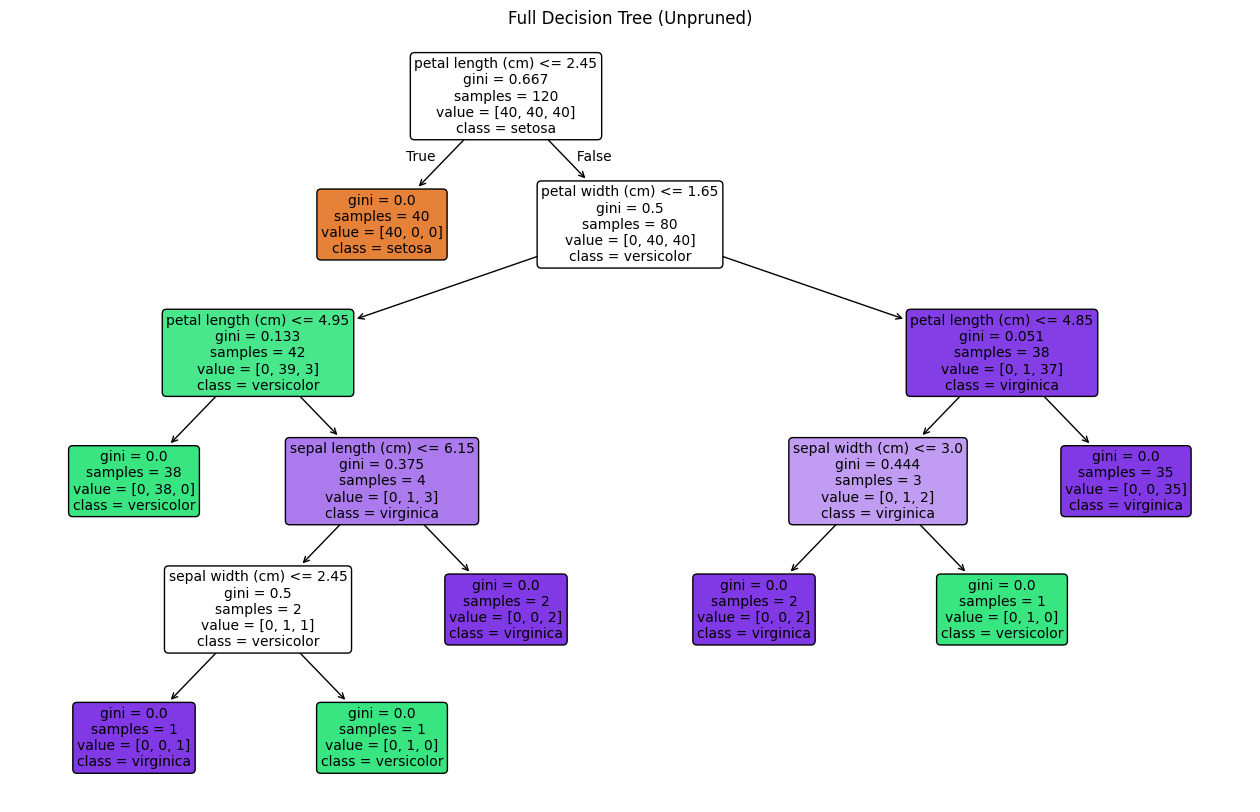

In [3]:
# Cell 3: Visualize the full tree
plt.figure(figsize=(16, 10))
plot_tree(tree_full, feature_names=X.columns, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10)
plt.title("Full Decision Tree (Unpruned)")
plt.show()

In [4]:
# Cell 4: Train pruned trees with different depth limits
results = []

for depth in [1, 2, 3, 4, 5]:
    tree_pruned = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_pruned.fit(X_train, y_train)
    y_pred = tree_pruned.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({'max_depth': depth, 'accuracy': acc, 'f1_score': f1})

results_df = pd.DataFrame(results)
print(results_df)

   max_depth  accuracy  f1_score
0          1  0.666667  0.555556
1          2  0.933333  0.933333
2          3  0.966667  0.966583
3          4  0.933333  0.933333
4          5  0.933333  0.933333


Pruned tree (depth=3) accuracy: 0.9666666666666667
Pruned tree (depth=3) F1-score: 0.9665831244778613

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



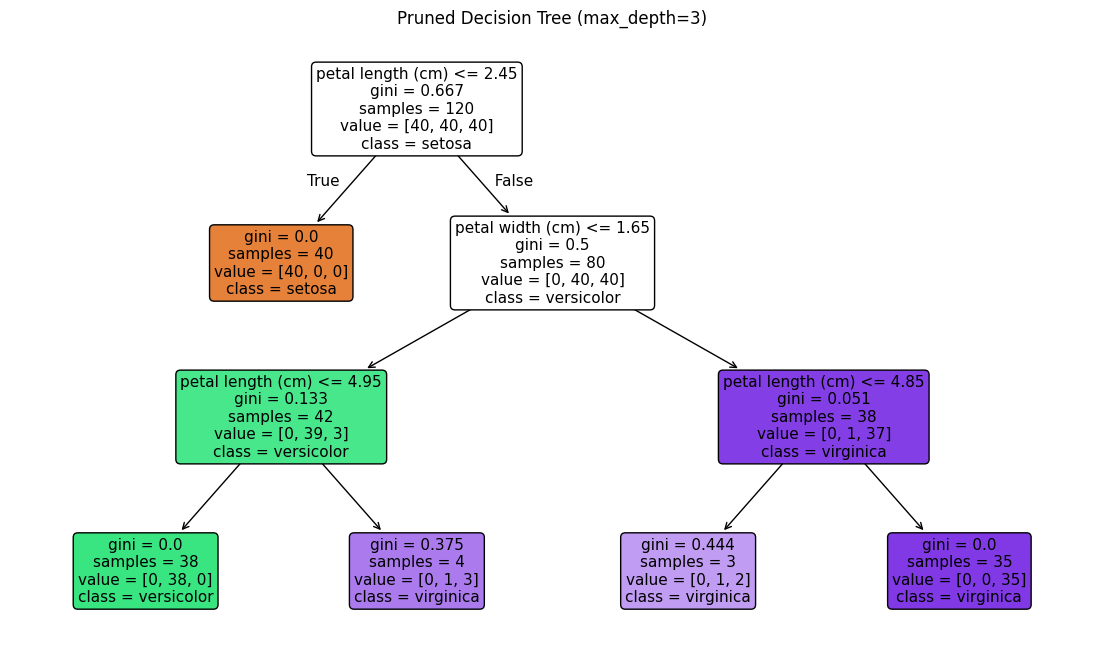

In [5]:
# Cell 5: Final pruned tree (depth=3)
tree_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_pruned.fit(X_train, y_train)
y_pred_pruned = tree_pruned.predict(X_test)

print("Pruned tree (depth=3) accuracy:", accuracy_score(y_test, y_pred_pruned))
print("Pruned tree (depth=3) F1-score:", f1_score(y_test, y_pred_pruned, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred_pruned, target_names=iris.target_names))

plt.figure(figsize=(14, 8))
plot_tree(tree_pruned, feature_names=X.columns, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=11)
plt.title("Pruned Decision Tree (max_depth=3)")
plt.show()

In [6]:
# Cell 6: Confusion matrix and summary
cm = confusion_matrix(y_test, y_pred_pruned)
print("Confusion Matrix:")
print(cm)

print("\n" + "="*50)
print("TASK 4 SUMMARY: Decision Trees for Classification")
print("="*50)
print(f"Dataset: Iris ({df.shape[0]} samples, 4 features, 3 classes)")
print(f"Train set: {X_train.shape[0]} | Test set: {X_test.shape[0]}")
print(f"\nFull tree (depth=5):    Accuracy = {accuracy_score(y_test, y_pred_full):.4f}")
print(f"Pruned tree (depth=3):  Accuracy = {accuracy_score(y_test, y_pred_pruned):.4f}")
print(f"\nKey insight: Pruning to max_depth=3 outperformed the unpruned")
print(f"tree, confirming the deeper tree was overfitting. Setosa is")
print(f"perfectly separable; the only confusion is between versicolor")
print(f"and virginica, a well-known hard case for this dataset.")

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

TASK 4 SUMMARY: Decision Trees for Classification
Dataset: Iris (150 samples, 4 features, 3 classes)
Train set: 120 | Test set: 30

Full tree (depth=5):    Accuracy = 0.9333
Pruned tree (depth=3):  Accuracy = 0.9667

Key insight: Pruning to max_depth=3 outperformed the unpruned
tree, confirming the deeper tree was overfitting. Setosa is
perfectly separable; the only confusion is between versicolor
and virginica, a well-known hard case for this dataset.
